# Tool Wear Monitor Application
Use the IntelliMaint package to create a tool wear monitoring application. 
Fill in your code in all the places labelled "Your code here". 


## Loading

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

"""
Tool Wear Monitoring notebook using Component for PSG Workshop Template

created: rachana.s@intellipredikt.com, shweta.s@intellipredikt.com

Last modified: July 22nd, 2026
"""

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import time
from matplotlib.ticker import MaxNLocator
from scipy.stats import kurtosis
from scipy.signal import stft, butter, filtfilt
from typing import Dict, Any, Optional, List
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel, Matern, DotProduct
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV, ParameterGrid, TimeSeriesSplit
from sklearn.preprocessing import PolynomialFeatures, RobustScaler, MinMaxScaler, StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Import the component template
from IntelliMaint.component_template import ComponentTemplate
# Import IntelliMaint modules
from IntelliMaint.intelliMaint_core import (
    DataAcquisition, SignalSeparation, SignalEnhancement, FeatureSelection, 
    TimeDomain, FrequencyDomain, HealthIndicatorConstructor, GPRDegradationModel
)

## Tool Data Loader

In [4]:
class ToolDataLoader(DataAcquisition):
    """
    Custom data loader for Tool data using DataAcquisition.
    """

    def __init__(self, config: Dict[str, Any]):
        super().__init__(config["data_loader"])
        self.log_file = config["data_loader"].get("log_file")
        self.data_dir = config["data_loader"].get("DATA_DIR_PATH")
        self.file_pattern = config["data_loader"].get("file_pattern")
        self.delimiter = config["data_loader"].get("delimiter")
        self.header = config["data_loader"].get("header")
        self.skiprows = config["data_loader"].get("skiprows")
        self.data_time_format = config['data_loader'].get('data_time_format')


## ToolFeatureExtractor

In [ ]:
class ToolFeatureEngineering(TimeDomain, FrequencyDomain):
    
    def __init__(self, config, simple_feat=True):
        """
        Initialize the feature engineering pipeline with configuration parameters.

        Args:
            config (dict): Configuration dictionary for feature engineering and signal separation.

        Uses Config Parameters:
            feature_engineering['sampling_rate'] (float or int): Sampling rate of signals.
            feature_engineering['window_size'] (int): Length of the window for analysis.
            feature_engineering['overlap'] (int): Frame overlap size.
            feature_engineering['max_level'] (int): Frame shift/max decomposition level.
            signal_separation['low_cutoff_freq'] (float): Lower cutoff for bandpass filter.
            signal_separation['high_cutoff_freq'] (float): Upper cutoff for bandpass filter.
            signal_separation['bandpass_filter_order'] (int): Order of bandpass filter.

        Returns:
            None
        """
        super().__init__(config["feature_engineering"])

        self.SE = SignalEnhancement(self.config)
        self.SS = SignalSeparation(self.config)

        self.simple_feat = simple_feat        
        
        self.sampling_rate = config["feature_engineering"].get("sampling_rate")
        self.window_len = config["feature_engineering"].get('window_size')
        self.frame_size = config["feature_engineering"].get('overlap')
        self.frame_shift = config["feature_engineering"].get('max_level')
        
        self.low_cutoff_freq = config["signal_separation"].get('low_cutoff_freq')
        self.high_cutoff_freq = config["signal_separation"].get('high_cutoff_freq')
        self.bandpass_filter_order = config["signal_separation"].get('bandpass_filter_order')

        
    
    def extract_features_from_file(self, data_df):
        """
        Extract features from a file or row, using either complex or simple extraction.

        Args:
            data_df (pd.DataFrame): Input vibration snapshot as DataFrame.

        Returns:
            dict or np.ndarray: Features extracted from the data depending on extraction mode.
        """
        data_df.columns = data_df.columns.str.strip()        
                                           
        if not self.simple_feat:
            # Extract features with spectral kurtosis
            features = self.extract_features_from_snapshot(data_df['X'], data_df['Y'], data_df['Z'])
        else:
            features = self.extract_simple_features(data_df)
            
        return features
    
    def extract_simple_features(self, signal_data):
        """
        Extract basic statistical features (mean, std, max, min, energy) and envelope features for X, Y, Z axes.

        Args:
            signal_data (pd.DataFrame): DataFrame containing signal columns ('X', 'Y', 'Z').

        Returns:
            np.ndarray: 1D array containing simple and envelope features for the snapshot.
        """
        features_list = []
        for column in signal_data.columns[:3]:
            signal = pd.to_numeric(signal_data[column], errors='coerce').dropna().values
            if len(signal) == 0:
                continue
            envelope = self.SE.calculate_envelope(signal)
            base_features = [np.mean(signal), np.std(signal), np.max(signal), np.min(signal), np.sum(signal ** 2)]
            features_list.extend(base_features + [np.mean(envelope), np.std(envelope)])
        return np.array(features_list)
    
    def extract_features_from_snapshot(self,x, y, z):
        """
        Extract comprehensive features including time-domain stats and envelope features 
        from a single vibration signal snapshot (three axes).

        Args:
            x (array-like): Vibration data for X-axis.
            y (array-like): Vibration data for Y-axis.
            z (array-like): Vibration data for Z-axis.

        Uses Config Parameters:
            sampling_rate (float or int): Sampling rate for kurtogram and envelope analysis.

        Returns:
            dict: Dictionary containing RMS, kurtosis, skewness, crest factor, and
                  optimal band envelope stats for all axes.
        """
        sampling_rate = self.sampling_rate         
        
        """Extract features from a vibration snapshot."""
        total_signal = np.sqrt(x**2 + y**2 + z**2)
        
        # Standard features
        rms = super().get_rms(total_signal) # Your code here to calculate RMS using the get_rms method from TimeDomain
        kurt_val = super().get_kurtosis(total_signal) # Your code here to calculate kurtosis using the get_kurtosis method from TimeDomain
        skew_val = super().get_skewness(total_signal) # Your code here to calculate skewness using the get_skewness method from TimeDomain
        crest = super().get_crestfactor(total_signal) # Your code here to calculate crest factor using the get_crest_factor method from TimeDomain
        
        
        # Spectral Kurtosis analysis for each axis
        sk_features = {}
        for axis_name, axis_signal in zip(['X', 'Y', 'Z'], [x, y, z]):
            
            # Quick kurtogram to find optimal band
            _, band, _ = self.compute_kurtogram(axis_signal, fs=sampling_rate, nlevel=5)
            # print("output band = ", band)
            
            # Apply bandpass filter with optimal band
            filtered = self.bandpass_filter(axis_signal,band[0],band[1],sampling_rate) # Your code here to apply bandpass filter using the bandpass_filter method from ToolFeatureEngineering on the axis_signal with the optimal band
            
            # Envelope analysis
            envelope = self.SE.calculate_envelope(filtered) # Your code here to calculate envelope fom SignalEnhancement on the filtered signal
            
            # Calculate features from envelope
            env_rms = super().get_rms(envelope) # Your code here
            env_peak = np.max(envelope) # Your code here
            env_kurt = super().get_kurtosis(envelope) # Your code here
            
            # Store in features dictionary
            sk_features[f'SK_Band_{axis_name}'] = band
            sk_features[f'SK_EnvRMS_{axis_name}'] = env_rms
            sk_features[f'SK_EnvPeak_{axis_name}'] = env_peak
            sk_features[f'SK_EnvKurt_{axis_name}'] = env_kurt
        
        # Combine all features
        features = {
            'RMS': rms,
            'Kurtosis': kurt_val,
            'Skewness': skew_val,
            'CrestFactor': crest,
            **sk_features
        }
        
        return features

    def compute_kurtogram(self, signal, fs=25600, nlevel=7):
        """
        Compute kurtogram to find the frequency band with maximum kurtosis in the input signal.

        Args:
            signal (array-like): Input vibration signal array.
            fs (float, optional): Sampling frequency. Default is 25600 Hz.
            nlevel (int, optional): Number of decomposition levels in kurtogram.

        Returns:
            tuple:
                - k_values (dict): Kurtosis values for each band.
                - opt_band (tuple): (low_freq, high_freq) optimal frequency band.
                - opt_bw (float): Bandwidth of optimal band.
        """
        # Simplified kurtogram implementation
        max_k = 0
        opt_band = (0, 0)
        opt_bw = 0
        k_values = {}
        
        # Loop through different window sizes (powers of 2)
        for level in range(2, nlevel + 1):
            win_size = 2 ** level
            if win_size >= len(signal):
                continue
                
            # Compute STFT with this window size
            overlap = win_size // 2  # 50% overlap
            f, sk = self.compute_spectral_kurtosis(signal, fs=fs, nperseg=win_size, noverlap=overlap)
            
            # Find peak kurtosis and corresponding frequency
            if len(sk) > 0:
                peak_k = np.max(sk)
                peak_idx = np.argmax(sk)
                if peak_idx < len(f):
                    peak_f = f[peak_idx]
                    
                    # Calculate bandwidth for this window size
                    bw = fs / win_size
                    
                    # Store in results
                    band_center = peak_f
                    band = (max(0, band_center - bw/2), min(fs/2, band_center + bw/2))
                    k_values[(band, bw)] = peak_k
                    
                    # Update optimal band if this has higher kurtosis
                    if peak_k > max_k:
                        max_k = peak_k
                        opt_band = band
                        opt_bw = bw
        
        return k_values, opt_band, opt_bw

    def normalize_with_absolute_ref(self, value, new_ref, worn_ref):
        """
        Normalize a value to [0, 1] using absolute references for 'new' and 'worn' conditions.

        Args:
            value (float): Measured value to normalize.
            new_ref (float): Reference value for the 'as-new' state.
            worn_ref (float): Reference value for the fully worn state.

        Uses Config Parameters:
            None

        Returns:
            float: Normalized value in the range [0.0, 1.0].
        """
        # Bound to 0-100% range
        if value <= new_ref:
            return 0.0
        elif value >= worn_ref:
            return 1.0
        else:
            # Linear interpolation between reference points
            return (value - new_ref) / (worn_ref - new_ref)
    

    def normalize(self,series):
        """
        Normalize a pandas Series to the [0, 1] range.

        Args:
            series (pd.Series): Series to be normalized.

        Uses Config Parameters:
            None

            
        Returns:
            pd.Series: Series scaled to [0, 1].
        """
        return (series - series.min()) / (series.max() - series.min()) if series.max() > series.min() else series

    def compute_spectral_kurtosis(self, signal, fs=25600, window='hann', nperseg=1024, noverlap=768):
        """
        Compute spectral kurtosis as a function of frequency using STFT.

        Args:
            signal (array-like): Input vibration signal.
            fs (float, optional): Sampling frequency. Default is 25600 Hz.
            window (str or tuple or array_like, optional): Desired window to use. Default is 'hann'.
            nperseg (int, optional): Length of each segment. Default is 1024.
            noverlap (int, optional): Number of points to overlap. Default is 768.

        Uses Config Parameters:
            None

        Returns:
            tuple:
                - f (np.ndarray): Array of sample frequencies.
                - sk (np.ndarray): Array of spectral kurtosis values for each frequency.
        """
        # Compute STFT
        f, t, Zxx = stft(signal, fs=fs, window=window, nperseg=nperseg, noverlap=noverlap)
        
        # Calculate magnitude
        magnitude = np.abs(Zxx)
        
        # Calculate kurtosis along time (axis=1)
        sk = np.zeros(len(f))
        for i, freq_bin in enumerate(magnitude):
            if np.std(freq_bin) > 0:  # Avoid division by zero
                sk[i] = kurtosis(freq_bin, fisher=True)  # Fisher's definition (excess kurtosis)
            else:
                sk[i] = 0
        
        return f, sk

    def bandpass_filter(self, signal, lowcut, highcut, fs, order=4):
        """Apply bandpass filter to signal."""
        nyquist = 0.5 * fs
        
        # Ensure frequencies are within valid range
        low = max(0.001, min(0.999, lowcut / nyquist))
        high = max(0.001, min(0.999, highcut / nyquist))
        
        # Ensure low < high
        if low >= high:
            low = high * 0.8  # Set low to 80% of high if there's an issue
            
        b, a = butter(order, [low, high], btype='band')
        return filtfilt(b, a, signal)
    
   

## Tool Feature Selection

In [6]:
class ToolFeatureSelection(FeatureSelection):
    def __init__(self, chunk_size=None, order=1):
        """
		Initialize the ToolFeatureSelection class with filtering parameters.

        Args:
            chunk_size (int, optional): Filtering window size for feature smoothing or grouping.
            order (int, optional): The order of the median filter applied to input features.

        Returns:
            None

		"""
        super().__init__()
        self.chunk_size = chunk_size
        self.feat_select = True

    def calculate_monotonicity(self, df):
        """
        Calculate monotonicity scores for all features in the input DataFrame.

        Args:
            df (pd.DataFrame): DataFrame containing prospective feature candidates for health indication.

        Returns:
            dict: Dictionary mapping feature names to their monotonicity scores.
        """
        return super().calculate_monotonicity(df) # Your code here to calculate monotonicity scores for each feature using the FeatureSelection class

## Tool Health Indicator Construction

In [7]:
class ToolHealthIndicatorConstruction(HealthIndicatorConstructor):
    def __init__(self, config, method="fused", cumulative_method=None):
        """
        Initialize ToolHealthIndicatorConstruction with given configuration.
        
        Args:
            config (dict): Configuration dictionary containing HI construction parameters.
        
        Uses Config Parameters:
            Passed to parent class; none directly used here.
        
        Returns:
            None
        """
        super().__init__(config)
        self.config = config
        self.cumulative_method = cumulative_method # Euclid or Mahalanobis distance method
        self.warn_threshold = self.config.get("tool_info", {}).get("warn_threshold", 60)  # Default warning threshold at 60% wear
        self.critical_threshold = self.config.get("tool_info", {}).get("critical_threshold", 80)  # Default critical threshold at 70% wear

    def set_operations_log(self, operations_log):
        self.operations_log = operations_log
    
    def construct_health_indicator(self, feature_df):
        """
        Compute a monotonic, cumulative health indicator (HI) using delta-based method without smoothing.

        Args:
            selected_features (pd.DataFrame): Feature dataframe including TimeStamp and relevant signals.
            
        Uses Config Parameters:
            None

        Returns:
            dict:
                - hybrid_hi (np.ndarray): Computed monotonic health indicator values.
                - time_hours (np.ndarray): Array of time steps (in hours) for computed HI.
                - train_size (int): Number of baseline points used for HI normalization.
        """
        data_time_format = self.config['data_loader'].get('data_time_format')
        feature_df['TimeStamp'] = feature_df['TimeStamp'].apply(lambda x: 
                                                                pd.to_datetime(os.path.splitext(
                                                                    os.path.basename(x))[0], format=data_time_format)) 
        feature_df = feature_df.sort_values('TimeStamp').reset_index(drop=True)
        feature_df.set_index("TimeStamp", drop=True, inplace=True)   
        print(f"Selected features are: {feature_df.head()} and have length {len(feature_df)}" )

        # Only take rows whose data was captured within the start and end times of the operations log
        indices_in_log = ((self.operations_log['start_time'].iloc[0] <= feature_df.index) & (feature_df.index <= self.operations_log['end_time'].iloc[-1]))
        feature_df = feature_df.loc[indices_in_log]

        # Convert the timestamps to get time in hours
        time_hours = np.arange(len(feature_df))* 5.0/60.0

        self.train_size = int(0.2 * len(feature_df))
        
        hi = super().compute_cumulative_hi(feature_df) # Your code here to calculate the health indicator using the HealthIndicatorConstructor class
        
        return {"hybrid_hi":hi, "time_hours":time_hours, "train_size": self.train_size}
    
    def plot_results(self, wear_percent, time_hours, training_size):
        """
        Plot tool wear percentage over time with warning and failure thresholds.

        Args:
            wear_percent (array-like): Predicted or actual wear percentage per cycle.
            time_hours (array-like): Time array aligned with wear_percent.
            training_size (int): Number of hours used in HI training (displayed at left).

        Returns:
            None: Displays the plot of wear mapping.

        """
        warn_thresh = self.warn_threshold/100
        critical_thresh = self.critical_threshold/100
        
        # Plot
        _, ax = plt.subplots(figsize=(14, 6))
        ax.plot(time_hours[training_size:], wear_percent, color='green', label='Wear % (from Exponential Hybrid HI)')
        ax.axhline(warn_thresh, color='orange', linestyle='--', label='⚠️ Warning Threshold (60%)')
        ax.axhline(critical_thresh, color='red', linestyle='--', label='⛔ Critical Threshold (80%)')

        ax.set_title("Tool Wear Mapping using Real Hybrid HI")
        ax.set_xlabel("Time (hour)")
        ax.set_ylabel("Wear Percentage (%)")
        ax.grid(True)
        ax.legend()
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
        ax.xaxis.set_major_locator(MaxNLocator(nbins=10))  # Set after all plot commands
        plt.tight_layout()
        plt.show()
        return
        

## Tool RUL Estimation

In [ ]:
class ToolRULEstimation(GPRDegradationModel):
    """
    Tool-level Remaining Useful Life (RUL) estimator using ensemble of Gaussian Process Regression (GPR) and polynomial regression.

    Args:
        config (dict): Configuration dictionary containing tool information and model settings.

    Uses Config Parameters:
        data_snapshot_duration (int/float): Duration for each tool data snapshot in time units.
    """
    def __init__(self, config, prediction_method='gpr', cross_valid=False):
        """
        Initialize the ToolRULEstimation model with all configuration parameters.

        Args:
            config (dict): Configuration dictionary containing tool information and model hyperparameters.

        Uses Config Parameters:
            tool_info["data_snapshot_duration"] (int/float): Duration for each data snapshot in tool operations.

        Returns:
            None
        """
        super().__init__(config)
        self.config = config
        
        self.data_snapshot_duration = config["tool_info"]["data_snapshot_duration"]
        self.prediction_method = prediction_method
        self.cross_valid = cross_valid
        self.kernels = {
            'RBF': RBF,
            'C': C,
            'WhiteKernel': WhiteKernel, 
            'Matern': Matern
        }
        self.warn_threshold = self.config.get("tool_info", {}).get("warn_threshold", 60)  # Default warning threshold at 60% wear
        self.critical_threshold = self.config.get("tool_info", {}).get("critical_threshold", 80)  # Default critical threshold at 80% wear


    def alpha_score(self, predicted_rul, true_rul):
        """
        Compute the alpha score, measuring normalized error between predicted and true RUL.

        Args:
            predicted_rul (pd.DataFrame): Predicted Remaining Useful Life values.
            true_rul (pd.DataFrame): True Remaining Useful Life values.

        Returns: 
            float: Alpha score - higher is better
        """
        return 1.0 - np.mean(np.abs(predicted_rul - true_rul) / (true_rul + 1e-6))

    def lambda_score(self, predicted_rul, true_rul, phi=13):
        """
        Calculate the lambda score to penalize overestimation and underestimation in RUL prediction.

        Args:
            predicted_rul (pd.DataFrame): Array of predicted Remaining Useful Life values.
            true_rul (pd.DataFrame): Array of ground-truth Remaining Useful Life values.
            phi (float, optional): Slope parameter for exponential penalty. Default is 13.

        Returns:
            float: Lambda score - average exponential penalty for RUL prediction deviation.
        """
        d = predicted_rul - true_rul
        score = np.where(d < 0,
                        np.exp(-d / phi) - 1,
                        np.exp(d / phi) - 1)
        return np.mean(score)        
    
    def set_monitoring_results(self, time_hours, train_size):
        self.time_hours = time_hours
        self.train_size = train_size


    def predict_rul_ensemble(self, observed_wear, **rul_args): 
        """
        Predict the Remaining Useful Life (RUL) and wear percentage using an ensemble
        of GPR and polynomial regression, trained from degradation onset.

        Args:
            **rul_args (dict):
                Arguments containing time series and wear or health index information:
                - time_hours (list): Array of time values.
                - hi (np.ndarray): Health indicator or wear fraction (0=healthy, 1=failed).
                - train_size (int): Number of samples in training window.

        Returns:
            dict: Dictionary with predicted wear, metrics, important times, and estimated RUL in hours.
        """
        
        time_hours = self.time_hours
        train_size = self.train_size
            
        # === Detect degradation onset ===
        # Define onset as first point where observed wear exceeds 60%
        onset_threshold = self.warn_threshold / 100  # 60% wear
        onset_mask = observed_wear >= onset_threshold
        if np.any(onset_mask):
            onset_idx = np.where(onset_mask)[0][0] 
        else:
            onset_idx = 0  # fallback if never crossed

        onset_hour = onset_idx*self.data_snapshot_duration/60.0
        self.anomaly_offset = onset_idx

        # Define critical as first point where observed wear exceeds 80%
        actual_threshold = self.critical_threshold / 100  # 80% wear
        actual_critical = observed_wear >= actual_threshold
        if np.any(actual_critical):
            actual_critical_idx = np.where(actual_critical)[0][0] + train_size
        else:
            actual_critical_idx = 0  # fallback if never crossed

        actual_critical_hour = actual_critical_idx*self.data_snapshot_duration/60.0

    
        # === Train GPR on wear directly ===
        X_train_size = onset_idx #int(0.4 * (len(observed_wear)-onset_idx))
        X_train = np.arange(0, X_train_size).reshape(-1, 1) #np.arange(onset_idx, onset_idx + X_train_size).reshape(-1, 1)
        y_train = observed_wear[0:X_train_size] #observed_wear[onset_idx:onset_idx + X_train_size]
        print(f"Size of the training dataset for gpr is {X_train_size} starting from {0}")

        # === Cross validation + Hyperparameter search ===
        if self.cross_valid:
            # GridSearch + Cross Validation
            self.gpr_model = GaussianProcessRegressor(
                n_restarts_optimizer=15,
                alpha=1e-4, # make this high
                normalize_y=True
            ) # Your code here to initialize the GaussianProcessRegressor from sklearn with a default kernel, alpha, and other parameters

            # Trying grid search for hyperparameter tuning for the kernels
            param_grid = {
                "kernel": [C(constant_value=1.0, constant_value_bounds=(1e-3, 1e3)) * 
                           (RBF(length_scale=lr, length_scale_bounds=(0.01, 100.0)) + DotProduct(sigma_0=sig)) + 
                            WhiteKernel(noise_level=nl)
                            for lr in np.logspace(-1, 1.5, 5)
                            for nl in np.logspace(-5, 0, 5)
                            for sig in (0,50,5)]                        
            }

            tscv = TimeSeriesSplit(n_splits=3)
            grid_search = GridSearchCV(estimator=self.gpr_model, 
                                       param_grid=param_grid, 
                                       cv=tscv, 
                                       scoring='neg_root_mean_squared_error')
            grid_search.fit(X_train, y_train)
            best_gpr = grid_search.best_estimator_

            print("Best Kernel = ", grid_search.best_params_)
            print("Best score = ", grid_search.best_score_)

        # Test set
        test_idx = onset_idx
        X_pred = np.arange(test_idx, len(observed_wear)).reshape(-1,1)#np.arange(onset_idx, len(observed_wear)).reshape(-1, 1) 
        print(f"Size of predicted wear for gpr is {len(X_pred)} starting from {test_idx}")

        # === Linear Regression on Polynomial Feature === 
        poly_features = PolynomialFeatures(degree=2)
        X_poly = poly_features.fit_transform(X_train)
        poly_model = LinearRegression() # Your code here to initialize the LinearRegression model from sklearn
        poly_model.fit(X_poly, y_train)

        
        X_pred_poly = poly_features.transform(X_pred)
        y_poly_pred = poly_model.predict(np.vstack([X_poly, X_pred_poly]))
    
        # Hyperparameter search obtained kernel
        if self.cross_valid:
            y_gpr_pred, y_gpr_std = best_gpr.predict(np.vstack([X_train, X_pred]), return_std=True)
        else:
            kernel = C(1.0, (1e-3, 1e3)) * (RBF(length_scale=10.0, length_scale_bounds=(0.01, 100.0)) + DotProduct(sigma_0=10.0)) + WhiteKernel()
            gpr_model = GaussianProcessRegressor(kernel=kernel, alpha=1e-4, n_restarts_optimizer=15, normalize_y=True) # Your code here
            gpr_model.fit(X_train, y_train)
            y_gpr_pred, y_gpr_std = gpr_model.predict(np.vstack([X_train, X_pred]), return_std=True)
        print("Confidence Interval for GPR predictions: ", 1.96 * y_gpr_std)
        print("Y_pred from GPR: ", y_gpr_pred)

        # Increase GPR weight over time
        alpha = np.linspace(0.5, 1.0, len(X_pred)+len(X_train))  # 0.3 for gpr, and 0.7 for poly 
        y_pred = (1 - alpha) * y_poly_pred + alpha * y_gpr_pred
        
        # y_pred = y_pred[onset_idx:]
        y_gpr_std = y_gpr_std[test_idx:]

        alpha_score = self.alpha_score(y_pred[test_idx:], observed_wear[test_idx:])
        lambda_score = self.lambda_score(y_pred[test_idx:], observed_wear[test_idx:])

        mae = mean_absolute_error(observed_wear[test_idx:], y_pred[test_idx:])
        rmse = np.sqrt(mean_squared_error(observed_wear[test_idx:], y_pred[test_idx:]))
        r2score = r2_score(observed_wear[test_idx:], y_pred[test_idx:])
        
        print("\n--- Validation Metrics ---")
        print(f"Ensemble — MAE: {mae:.4f}, "
            f"RMSE: {rmse:.4f}, "
            f"R²: {r2score:.4f}, "
            f"Alpha Score: {alpha_score:.4f}, "
            f"Lambda Score: {lambda_score:.4f}")
        
        metrics = {
            "rmse": rmse,
            "mae": mae,
            "R2 score": r2score,
            "alpha score": alpha_score,
            "lambda score": lambda_score
        }       

        predicted_wear = y_pred
    
        # === Detect degradation ===
        # For predicted wear, obtain warning and critical points
        warning_threshold = self.warn_threshold / 100  # 60% wear   
        warning_mask = predicted_wear >= warning_threshold
        if np.any(warning_mask):
            warning_idx = np.where(warning_mask)[0][0] + train_size
            warning_time = warning_idx * self.data_snapshot_duration/60.0
            # print(f" Warning Point: At hour {warning_time} (wear ≥ 80%) for file index {warning_idx}")
        else:
            print("Predicted wear doesn't cross 60% threshold")

        # Find critical point — first predicted wear ≥ 80%
        fail_threshold = self.critical_threshold / 100  # 80% wear
        failure_mask = predicted_wear >= fail_threshold
        if np.any(failure_mask):
            critical_idx = np.where(failure_mask)[0][0] + train_size # + test_idx#onset_idx 
            critical_time = critical_idx * self.data_snapshot_duration/60.0
            # print(f" Critical Point: At hour {critical_time} (wear ≥ 80%) for file index {critical_idx}")
        else:
            critical_time = actual_failure_hour  # fallback
            print(" No critical point found — fallback to failure")

        # Define failure point as last prediction cycle
        actual_failure_idx = len(time_hours) - 1  # 88 in your case
        actual_failure_hour = actual_failure_idx * self.data_snapshot_duration/60.0

        predicted_failure_idx = np.where(predicted_wear>1)[0][0] + train_size - 1
        # print(f" Predicted Failure Index: {predicted_failure_idx}")
        predicted_failure_hour = predicted_failure_idx * self.data_snapshot_duration/60.0
        
        # From degradation onset to failure
        rul_from_onset_idx = predicted_failure_idx - warning_idx
        rul_from_onset_hours = rul_from_onset_idx * self.data_snapshot_duration/60.0
        
        # From critical point to failure
        rul_from_critical_idx = predicted_failure_idx - critical_idx
        rul_from_critical_hours = rul_from_critical_idx * self.data_snapshot_duration/60.0 # instead directly multilping each file with 16 which is not true
        
        # Logging
        print(f" Actual Warning time: at {(onset_idx + train_size)*5.0/60.0}")
        print(f" Predicted Warning time: at {warning_time}")
        print(f" Actual Critical time: at {actual_critical_hour}")
        print(f" Predicted Critical time: at {critical_time}")
        print(f" Predicted Failure: at {predicted_failure_hour}")
        print(f" Actual Failure: at {actual_failure_hour}")
        print(f" Estimated RUL from Onset: at {warning_time} hours → {rul_from_onset_hours:.2f} hours")
        print(f" Estimated RUL from Critical: at {critical_time} hours → {rul_from_critical_hours:.2f} hours")


        # === Plot Predicted Wear ===
        # Set a global default font size for all text elements
        _, ax1 = plt.subplots(nrows=1,ncols=1,figsize=(18, 7))
                
        ax1.plot(time_hours[train_size:], observed_wear * 100, 'k.-', label='Wear %')
        ax1.axhline(60, color='gold', linestyle='--', linewidth=2,
            label='Warning Threshold (60%)')
        ax1.axhline(fail_threshold * 100, color='purple', linestyle='--', label=f' Critical Threshold ({fail_threshold * 100:.0f}%)')
        ax1.axhline(100, color='red', linestyle='--', label=f' Failure ({100:.0f}%)')

        ax1.axvline(actual_failure_hour, color='green', linestyle='-.',
                    label=f'Actual Complete Failure @ {actual_failure_hour:.2f} hours ') 


        if predicted_failure_idx:
            ax1.axvline(predicted_failure_hour, color='red', linestyle='-.',
                        label=f'Predicted Complete Failure @ {predicted_failure_hour:.2f} hours') # changed rul_hours to rul_from_critical_hours

        ax1.plot(time_hours[train_size:], predicted_wear * 100, 'b-', label='GPR Forecast (Wear %)')
        ax1.fill_between(time_hours[train_size+test_idx:],
                        np.clip(y_pred[test_idx:] - 2 * y_gpr_std, 0, 1) * 100,
                        np.clip(y_pred[test_idx:] + 2 * y_gpr_std, 0, 1) * 100,
                        color='blue', alpha=0.2, label='95% CI')
        
        ax1.annotate(f"RUL: {rul_from_onset_hours:.2f} hrs",
             xy=(warning_time, 60), xytext=(onset_hour, 75),
             arrowprops=dict(arrowstyle="->", color='black'),
             fontsize=19, color='black')

        ax1.annotate(f"RUL: {rul_from_critical_hours:.2f} hrs",
             xy=(critical_time, 80), xytext=(critical_time, 93),
             arrowprops=dict(arrowstyle="->", color='black'),
             fontsize=19, color='black')
        
        ax1.set_ylabel("Wear (%)", color='black')
        ax1.legend(fontsize=15)       
        ax1.set_ylim(0,110)
        
        plt.title("Tool Wear Forecast")
        plt.xlabel("Time (hours)")
        plt.grid(True)
        plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')
        ax1.xaxis.set_major_locator(MaxNLocator(nbins=10))  # Set after all plot commands
        plt.tight_layout()
        plt.show()
    
        if predicted_failure_idx:
            print(f" Predicted Failure Cycle: {predicted_failure_idx}")
            print(f" Estimated RUL: {rul_from_critical_hours:.2f} hours") #changed rul_hours to rul_from_critical_hours
    
        return {
            "predicted_wear": y_pred, 
            "metrics": metrics,
            "onset_hour": onset_hour,
            "critical_time": critical_time,
            "predicted_failure_hour": predicted_failure_hour,
            "rul_from_onset_hours": rul_from_onset_hours,
            "rul_from_critical_hours": rul_from_critical_hours
        }

## Tool Wear Monitor

In [ ]:
class ToolWearMonitor(ComponentTemplate):
    """
    Component template-based monitor for tool wear analysis.
    Direct port of the standalone tool wear monitoring script.
    """
    def __init__(self, 
                 config=None, 
                 simple_feat=True, 
                 hi_method="fused",
                 hi_cumulative_method=None, 
                 prediction_method="gpr", 
                 cross_valid=False):
        
        self.config = config
        self.simple_feat = simple_feat
        self.hi_method = hi_method
        self.hi_cumulative_method = hi_cumulative_method
        self.prediction_method = prediction_method
        self.cross_valid = cross_valid
        super().__init__(config)

                       
    def _init_data_acquisition(self):
        return ToolDataLoader(self.config)

    def _init_signal_processing(self):
        return None

    def _init_feature_selection(self):
        return ToolFeatureSelection(self.config)

    def _init_feature_engineering(self):
        return ToolFeatureEngineering(self.config, 
                                      simple_feat=self.simple_feat)
    
    def _init_anomaly_detection(self):
        return None

    def _init_health_indicator_construction(self):
        return ToolHealthIndicatorConstruction(self.config, 
                                               method=self.hi_method,
                                               cumulative_method=self.hi_cumulative_method)
    
    def _init_fault_classifier(self):
        return None
        
    def _init_diagnostic_evaluator(self):
        return None
    
    def _init_degradation_detector(self):
        return None

    def _init_degradation_modeler(self):
        return None

    def _init_rul_estimation(self):
        return ToolRULEstimation(self.config, 
                                 prediction_method=self.prediction_method, 
                                 cross_valid=self.cross_valid)
    
    def validate_config(self) -> bool:
        """Validate configuration parameters."""
        required_sections = ["tool_info", "data_loader", "feature_engineering", "monitoring"]
        
        for section in required_sections:
            if section not in self.config:
                raise ValueError(f"Missing required config section: {section}")
        
        # Check required tool_info parameters
        required_tool_info = [
            "tool_id", "operation", "cycle_time_sec", "depth_of_cut_mm", 
            "feed_rate", "rpm", "initial_freq_range", "warning_threshold", 
            "critical_threshold", "new_tool_reference", "worn_tool_reference",
            "mqe_warning_threshold", "mqe_critical_threshold"
        ]
        
        for param in required_tool_info:
            if param not in self.config["tool_info"]:
                raise ValueError(f"Missing required parameter in tool_info: {param}")
        
        return True   
    
    
    def monitor(self):
        """
        Run the monitoring process to estimate Remaining Useful Life Estimation
        """

        # === Get the tool ID ===
        tool_id = self.config['tool_info']['tool_id']
        print(f"Analyzing tool wear for {tool_id}...")
        
        # === Load Operation Log ===

        operations_log = pd.read_csv(self.config['data_loader']['log_file'])
        operations_log.columns = operations_log.columns.str.strip()

        # Convert timestamps to datetime
        operations_log['start_time'] = pd.to_datetime(operations_log['Timestamp start_time'].str.lstrip(), 
                                                      format=self.config['data_loader']['data_time_format'])
        operations_log['end_time'] = pd.to_datetime(operations_log['End_time'].str.lstrip(), 
                                                    format=self.config['data_loader']['data_time_format'])
        operations_log['tool_id'] = operations_log['Tool id']
        operations_log['operation'] = operations_log['Operation']
        self.health_indicator_construction.set_operations_log(operations_log)


        # === Step 1: Load Data from files and Extract Features ===
        monitoring_results = super().monitor() # Your code here to do monitoring
        
        # === Display the monitoring results ===
        print("Monitoring Results:")
        print(f"Features DataFrame: {monitoring_results['features'].head()}")
        print(f"Time (hours): {monitoring_results['health_indicator']['time_hours']}")
        print(f"Health Indicator: {monitoring_results['health_indicator']['hybrid_hi']}")
        print(f"Train Size: {monitoring_results['health_indicator']['train_size']}")

        

        # === Step 2: Extract health indicator results ===
        time_hours = monitoring_results['health_indicator']['time_hours'] 
        hi =  monitoring_results['health_indicator']['hybrid_hi'] 
        
        train_size = monitoring_results['health_indicator']['train_size']

        # Plot the health Indicator over time
        self.health_indicator_construction.plot_results(
            wear_percent=hi,
            time_hours=time_hours,
            training_size=train_size
        )

        # === Step 3: Predict remaining useful life ===
        self.rul_estimation.set_monitoring_results(time_hours, train_size)
        gpr_results = super().predict_rul(hi=1-hi) # Your code here

        results = {
            'feature_df': monitoring_results['features'],
            'Degradation onset': gpr_results["onset_hour"],
            'RMSE': gpr_results["metrics"]['rmse'],
            'Failure time': gpr_results['predicted_failure_hour'],
            'RUL at Warning': gpr_results['rul_from_onset_hours'], 
            'RUL at Critical': gpr_results['rul_from_critical_hours']
        }

        return results  
    

In [11]:
# Configuration for tool wear monitoring
config = {
    'data_loader': {
        'file_pattern': '*.csv',
        'delimiter': ',',
        'header': 0,
        'skiprows': 0,
        'numeric_only': False,
        'data_time_format': '%Y-%m-%d %H-%M-%S'
    },
    'feature_engineering': {
        'sampling_rate': 25600,  # Hz
        'window_size': 1024,  # FFT window size
        'overlap': 0.75,  # Overlap between windows (75%)
        'max_level': 7  # Maximum level of the kurtogram
    },
    'signal_separation': {
        'sampling_rate': 25600,
        'low_cutoff_freq': 1000,
        'high_cutoff_freq': 12000,
        'bandpass_filter_order': 4
    },
    'tool_info': {
        'tool_id': 'CNMG04',
        'operation': 'Facing',
        'sample_frequency': 5,
        'depth_of_cut_mm': 0.5,
        'feed_rate': 0.3,
        'data_snapshot_duration': 5.0, 
        'rpm': 1500,
        # Frequency bands to explore for SK analysis
        'initial_freq_range': (1000, 12000),
        # Baseline thresholds (to be calibrated)
        'warning_threshold': 60,
        'critical_threshold': 80,
        'new_tool_reference': 0.5,    # Cumulative wear value for a new tool
        'worn_tool_reference': 40.0,   # Cumulative wear value for a fully worn tool CHANGED AFTER LOOKING AT CUMULATIVE WEAR VALUES
        'mqe_warning_threshold': 1000,  # MQE value that indicates warning level
        'mqe_critical_threshold': 10000  # MQE value that indicates critical level
    },

    'wear_thresholds': {
        'initial_wear': 15,
        'moderate_wear': 35,
        'excessive_wear': 60,
        'severe_wear': 80,
        'tool_failure': 95
    },

    'monitoring': {
        'window_size': 3,  # Rolling window size for smoothing
        'min_consecutive': 3,  # Minimum consecutive anomalies to consider as wear
        'baseline_size': 50  # Number of samples to use as baseline
    }
} 

## Main

2026-07-21 17:52:49,230 [INFO] ToolDataLoader: Initialized DataAcquisition with config: {'DATA_DIR_PATH': 'D:\\Rachana\\Data Collection PSG May-June2025\\MildSteel_complete_vibration_data', 'file_pattern': '*.csv', 'delimiter': ',', 'header': 0, 'skiprows': 0, 'mat_variable': None}
2026-07-21 17:52:49,232 [INFO] ToolFeatureSelection: Initialized FeatureSelection with chunk_size=None, order=1
2026-07-21 17:52:49,234 [INFO] SignalEnhancement: Initialized SignalEnhancement with config: {'sampling_rate': 25600, 'segment_length': 50, 'filter_length': 11, 'iterations': 10, 'spectral_kurtosis_window_lengths': 256, 'bearing_frequencies': [20, 40, 60], 'rpm': 2000, 'num_sidebands': 2, 'window_len': 25600, 'frame_size': 25600, 'frame_shift': 50, 'window_size': 1024, 'overlap': 0.75, 'max_level': 7}
2026-07-21 17:52:49,237 [INFO] SignalSeparation: Initialized SignalSeparation with config: {'sampling_rate': 25600, 'low_cutoff_freq': 50, 'high_cutoff_freq': 100, 'lowpass_filter_order': 4, 'highpass

Analyzing tool wear for CNMG04...


2026-07-21 17:53:08,095 [INFO] ToolFeatureSelection: Calculating monotonicity scores
2026-07-21 17:53:08,102 - ToolWearMonitor - INFO - Monotonic Feature: SK_EnvKurt_Y, Score: 0.172
2026-07-21 17:53:08,103 - ToolWearMonitor - INFO - Monotonic Feature: SK_EnvPeak_X, Score: 0.080
2026-07-21 17:53:08,105 - ToolWearMonitor - INFO - Monotonic Feature: SK_EnvKurt_X, Score: 0.080
2026-07-21 17:53:08,109 - ToolWearMonitor - INFO - Monotonic Feature: SK_EnvPeak_Y, Score: 0.057
2026-07-21 17:53:08,111 - ToolWearMonitor - INFO - Monotonic Feature: RMS, Score: 0.034
2026-07-21 17:53:08,114 - ToolWearMonitor - INFO - Monotonic Feature: CrestFactor, Score: 0.034
2026-07-21 17:53:08,115 - ToolWearMonitor - INFO - Monotonic Feature: SK_EnvRMS_X, Score: 0.034
2026-07-21 17:53:08,222 [INFO] ToolHealthIndicatorConstruction: Computing cumulative health indicator


Selected features are:                      SK_EnvKurt_Y  SK_EnvPeak_X  SK_EnvKurt_X  SK_EnvPeak_Y  \
TimeStamp                                                                     
2025-05-29 14:35:37     -0.105799      0.002106     -0.628319      0.001837   
2025-05-29 14:40:37     -0.239363      0.002329      1.113333      0.002333   
2025-05-29 15:05:10      0.809237      0.002051      0.165096      0.002838   
2025-05-29 15:05:37      0.307723      0.001972     -0.426618      0.002541   
2025-05-31 12:10:37     -0.529730      0.002446      0.389438      0.001031   

                          RMS  CrestFactor  SK_EnvRMS_X  
TimeStamp                                                
2025-05-29 14:35:37  0.367727     2.840972     0.000983  
2025-05-29 14:40:37  0.392099     2.723293     0.000865  
2025-05-29 15:05:10  0.344542     3.546276     0.000979  
2025-05-29 15:05:37  0.156341     3.017112     0.000834  
2025-05-31 12:10:37  0.347823     3.701647     0.001020   and have length 8

C:\Users\HP\AppData\Local\Temp\ipykernel_29916\4031222122.py:90: UserWarning: Glyph 9940 (\N{NO ENTRY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\HP\anaconda3\envs\intellimaint_dist_1.0.7\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9940 (\N{NO ENTRY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


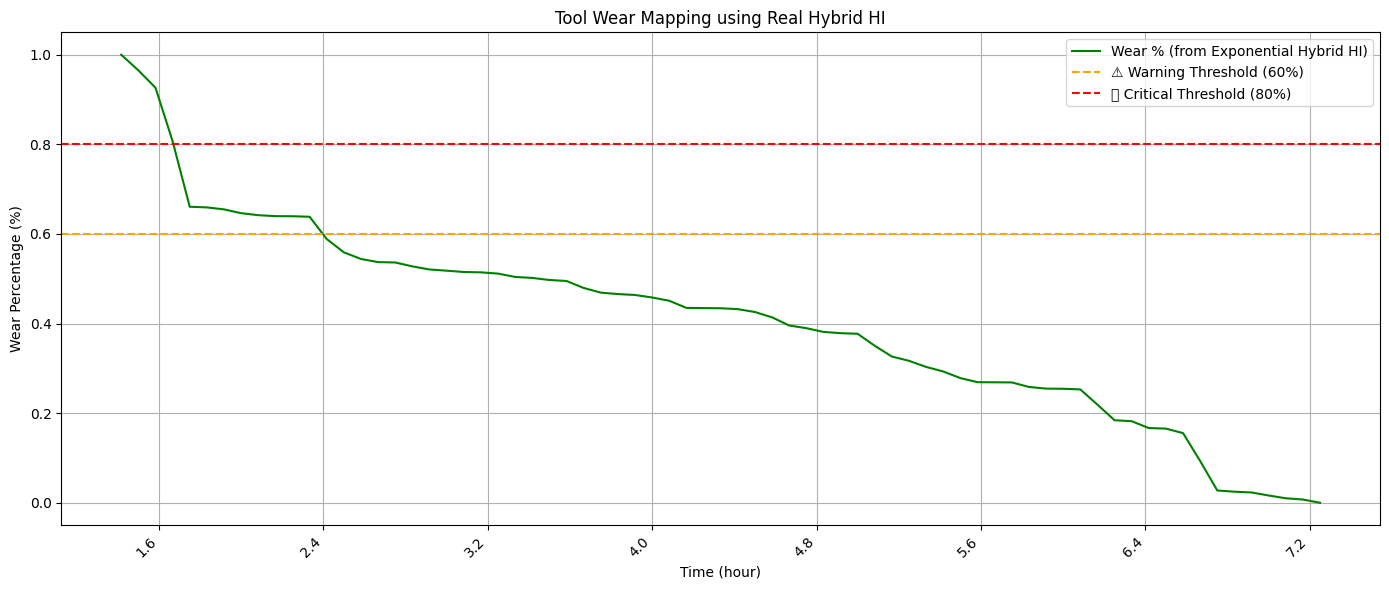

Size of the training dataset for gpr is 39 starting from 0
Size of predicted wear for gpr is 32 starting from 39


c:\Users\HP\anaconda3\envs\intellimaint_dist_1.0.7\Lib\site-packages\sklearn\gaussian_process\_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 13 iteration(s) (status=2):
ABNORMAL_TERMINATION_IN_LNSRCH

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


Confidence Interval for GPR predictions:  [0.02769138 0.02507431 0.02479029 0.02464976 0.02460981 0.02457845
 0.02457481 0.02457039 0.024569   0.02456695 0.02456694 0.02456687
 0.02456673 0.02456651 0.02456648 0.02456647 0.02456644 0.0245664
 0.02456639 0.0245664  0.0245664  0.02456641 0.02456645 0.02456649
 0.0245665  0.02456653 0.02456676 0.02456691 0.02456697 0.02456697
 0.02456906 0.02457048 0.02457483 0.02457845 0.02460994 0.02465022
 0.02479029 0.02507507 0.02769477 0.05375776 0.09761807 0.1376509
 0.16371816 0.17739098 0.1841645  0.18802284 0.19085741 0.19340828
 0.19592487 0.19847586 0.20107521 0.20372386 0.2064203  0.20916274
 0.21194939 0.21477854 0.21764852 0.22055775 0.22350468 0.22648786
 0.22950586 0.23255733 0.23564096 0.23875552 0.24189981 0.24507268
 0.24827304 0.25149984 0.25475207 0.25802878 0.26132903]
Y_pred from GPR:  [0.0076379  0.01883052 0.08993655 0.20529917 0.30753105 0.35229748
 0.35269407 0.34937532 0.3558354  0.35914986 0.35851067 0.37149352
 0.40419094 0.

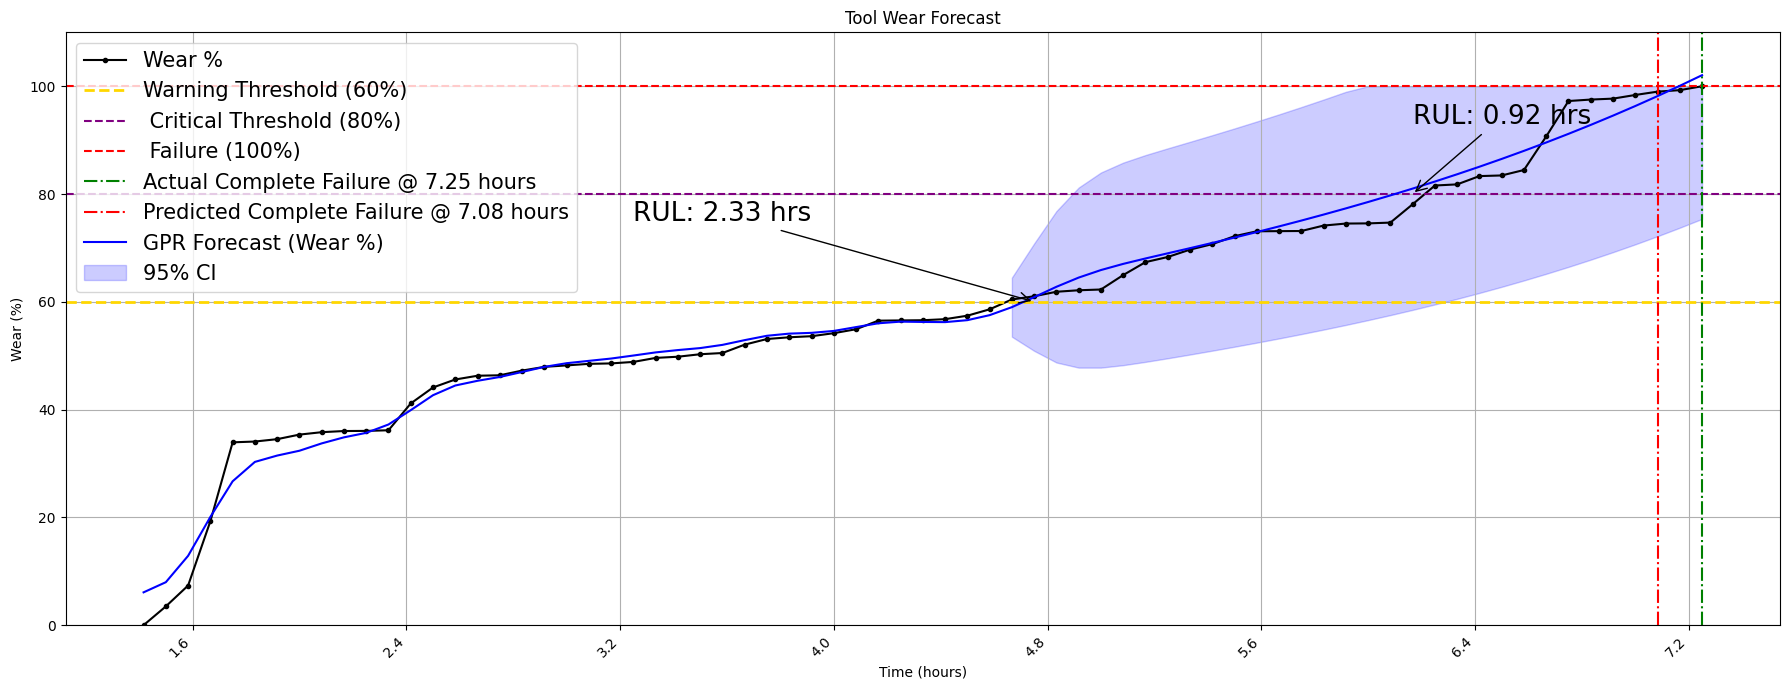

 Predicted Failure Cycle: 85
 Estimated RUL: 0.92 hours

Monitoring and Predicting completed successfully!

Summary:
  - Processed features: 88 samples
  - Remaining Useful Life: 2.3333333333333335
Time taken to execute is 25 seconds


In [ ]:
"""
Example usage of the ToolWearMonitor component
"""

if __name__ == "__main__":
    st = time.time()
    # Pass in the path to the log file
    config['data_loader']['log_file'] = r"D:\Rachana\Data Collection PSG May-June2025\tool_operations_log_04-06-2025_Daywise.csv"

    # Pass in the path to the Tool wear data 
    config['data_loader']['DATA_DIR_PATH'] = input("Enter the full path of the directory containing tool vibration data files: ") or \
                                                   r"D:\Rachana\Data Collection PSG May-June2025\MildSteel_complete_vibration_data"
    
    # Initialize the tool wear monitor with configuration
    monitor = ToolWearMonitor(config, 
                              simple_feat=False, 
                              hi_method="cumulative",
                              hi_cumulative_method="euclid",  
                              prediction_method="ensemble", 
                              cross_valid=False)
    
    # Run the monitoring process
    results = monitor.monitor()
    
    if results:
        print("\nMonitoring and Predicting completed successfully!")
        
        # Access different result components
        feature_df = results['feature_df']
        
        print(f"\nSummary:")
        print(f"  - Processed features: {len(feature_df)} samples")
        print(f"  - Remaining Useful Life: {results["RUL at Warning"]}")

    en = time.time()
    print(f"Time taken to execute is {(en-st):.0f} seconds")